In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load state-level competitiveness dataset
states = pd.read_csv("../sources/state_competitiveness.csv")

states.head()

,State,Electricity_Price_cents_per_kWh,Grid_Capacity_MW,Renewable_Share_Percent,Carbon_Intensity_kgCO2_per_kWh,Power_Reliability_Score,Transmission_Congestion_Score,Land_Availability_Score,Water_Stress_Score,Existing_Data_Center_Ecosystem_Score,...,Load_Growth_Pressure_Percent,Power_Delivery_Risk_Score,Natural_Gas_Price_USD_per_MMBtu,Solar_Resource_Score,Geothermal_Potential_Score,Nuclear_Capacity_MW,Behind_The_Meter_Potential_Score,Regional_Competitiveness_Score,Interconnection_Region,Interconnection_Friction_Score
0,Texas,9.79,168317,14.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ERCOT,1.00
1,Virginia,10.62,29147,6.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PJM,0.55
2,Arizona,12.74,32877,7.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Western Interconnection,0.75
3,California,27.04,96773,34.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CAISO,0.20
4,Nevada,11.47,16725,22.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Western Interconnection,0.75


In [13]:
# Price score: lower electricity price is better
states["price_score"] = (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"]
) / (
    states["Electricity_Price_cents_per_kWh"].max()
    - states["Electricity_Price_cents_per_kWh"].min()
)

# Capacity score: higher installed generation capacity is better
states["capacity_score"] = (
    states["Grid_Capacity_MW"]
    - states["Grid_Capacity_MW"].min()
) / (
    states["Grid_Capacity_MW"].max()
    - states["Grid_Capacity_MW"].min()
)

# Renewable score: higher renewable share is better
states["renewable_score"] = (
    states["Renewable_Share_Percent"]
    - states["Renewable_Share_Percent"].min()
) / (
    states["Renewable_Share_Percent"].max()
    - states["Renewable_Share_Percent"].min()
)

# Existing data center ecosystem score
data_center_counts = {
    "Virginia": 609,
    "Texas": 467,
    "California": 287,
    "Georgia": 219,
    "Ohio": 210,
    "Arizona": 156,
    "Washington": 103,
    "North Carolina": 93,
    "Oregon": 125,
    "Nevada": 71,
    "Utah": 43,
    "Pennsylvania": 131,
    "Illinois": 228,
    "Indiana": 122,
    "Tennessee": 61
}

states["data_center_count"] = states["State"].map(data_center_counts)

states["ecosystem_score"] = (
    states["data_center_count"] - states["data_center_count"].min()
) / (
    states["data_center_count"].max()
    - states["data_center_count"].min()
)

# Interconnection score is already 0-1
states["interconnection_score"] = states["Interconnection_Friction_Score"]

states[
    [
        "State",
        "price_score",
        "capacity_score",
        "renewable_score",
        "ecosystem_score",
        "interconnection_score"
    ]
].head()

,State,price_score,capacity_score,renewable_score,ecosystem_score,interconnection_score
0,Texas,1.000000,1.000000,0.280353,0.749117,1.00
1,Virginia,0.951884,0.119400,0.099338,1.000000,0.55
2,Arizona,0.828986,0.143002,0.112583,0.199647,0.75
3,California,0.000000,0.547304,0.706402,0.431095,0.20
4,Nevada,0.902609,0.040800,0.448124,0.049470,0.75


In [14]:
score_columns = [
    "price_score",
    "capacity_score",
    "renewable_score",
    "ecosystem_score",
    "interconnection_score"
]

states[score_columns].describe()

,price_score,capacity_score,renewable_score,ecosystem_score,interconnection_score
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,0.855614,0.210402,0.274761,0.268551,0.630000
std,0.241981,0.253215,0.331380,0.278107,0.181068
min,0.000000,0.000000,0.000000,0.000000,0.200000
25%,0.875942,0.088231,0.083885,0.097173,0.525000
50%,0.907826,0.130967,0.099338,0.155477,0.650000
75%,0.943768,0.207134,0.364238,0.318905,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
n_simulations = 10_000
np.random.seed(42)

results = []

for i in range(n_simulations):
    weights = np.random.dirichlet(np.ones(len(score_columns)))
    
    simulation_scores = states[score_columns].values @ weights
    
    winner_index = np.argmax(simulation_scores)
    winner_state = states.iloc[winner_index]["State"]
    
    results.append({
        "simulation": i,
        "winner": winner_state,
        **{f"weight_{col}": weight for col, weight in zip(score_columns, weights)}
    })

simulation_results = pd.DataFrame(results)

simulation_results.head()

,simulation,winner,weight_price_score,weight_capacity_score,weight_renewable_score,weight_ecosystem_score,weight_interconnection_score
0,0,Texas,0.079825,0.512038,0.223986,0.155297,0.028854
1,1,Washington,0.038624,0.013628,0.458035,0.209311,0.280403
2,2,Texas,0.003617,0.609298,0.310675,0.041510,0.034900
3,3,Texas,0.091305,0.163472,0.335246,0.254855,0.155122
4,4,Texas,0.377441,0.059918,0.137802,0.181977,0.242862


In [16]:
winner_frequency = (
    simulation_results["winner"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

winner_frequency.columns = ["State", "Winner_Frequency_Percent"]

winner_frequency

,State,Winner_Frequency_Percent
0,Texas,78.43
1,Washington,17.44
2,Virginia,4.13


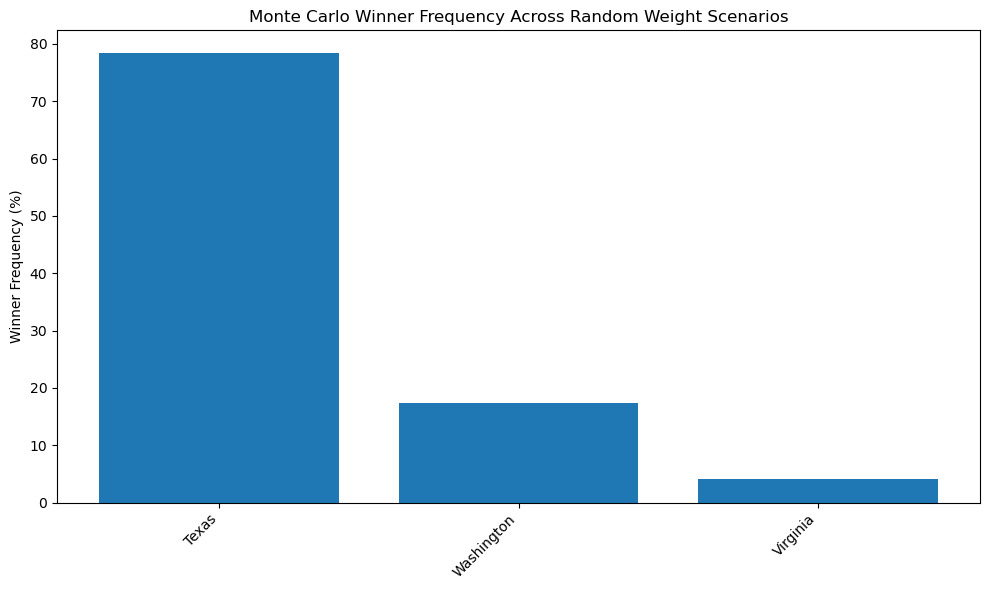

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    winner_frequency["State"],
    winner_frequency["Winner_Frequency_Percent"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Winner Frequency (%)")
plt.title("Monte Carlo Winner Frequency Across Random Weight Scenarios")
plt.tight_layout()

plt.show()

In [18]:
# Store full simulated scores for every state
score_records = []

for i in range(n_simulations):
    weights = np.random.dirichlet(np.ones(len(score_columns)))
    simulation_scores = states[score_columns].values @ weights
    
    for state, score in zip(states["State"], simulation_scores):
        score_records.append({
            "simulation": i,
            "State": state,
            "score": score
        })

score_distribution = pd.DataFrame(score_records)

score_distribution.head()

,simulation,State,score
0,0,Texas,0.894474
1,0,Virginia,0.757013
2,0,Arizona,0.505407
3,0,California,0.260071
4,0,Nevada,0.492777


/var/folders/h_/6xwp29sx51bb6tfjw793j8z80000gn/T/ipykernel_49949/626925381.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


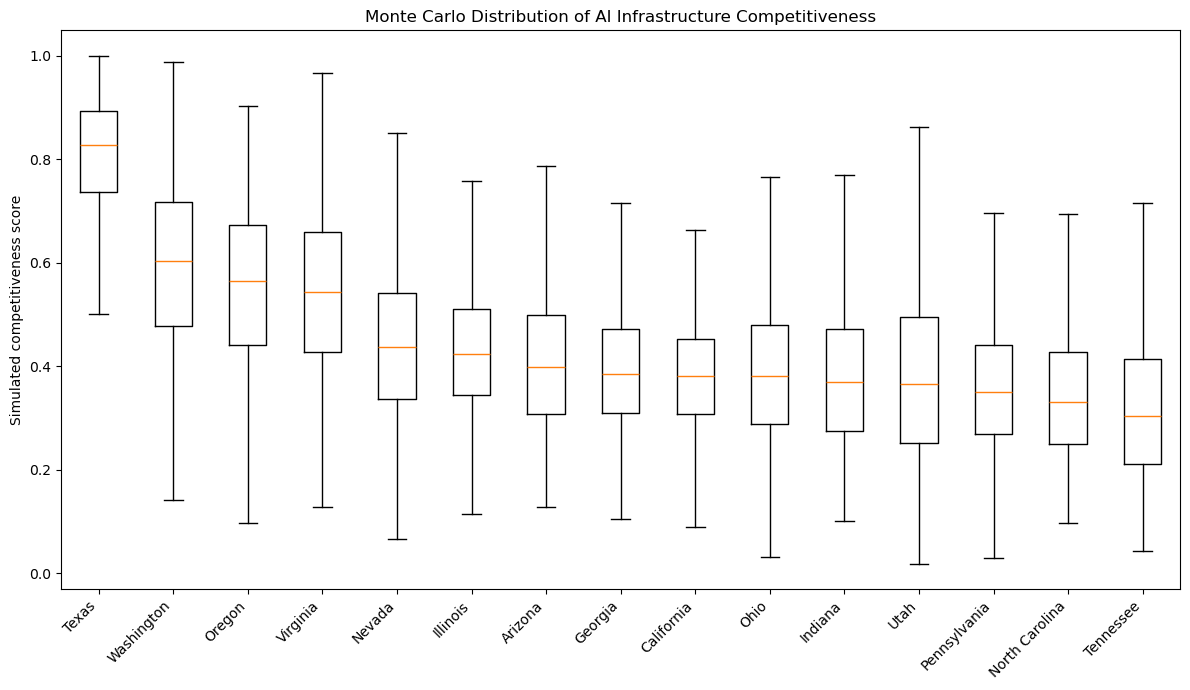

In [19]:
# Order states by median simulated score
state_order = (
    score_distribution
    .groupby("State")["score"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 7))

data_to_plot = [
    score_distribution.loc[score_distribution["State"] == state, "score"]
    for state in state_order
]

plt.boxplot(
    data_to_plot,
    labels=state_order,
    showfliers=False
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Simulated competitiveness score")
plt.title("Monte Carlo Distribution of AI Infrastructure Competitiveness")
plt.tight_layout()

plt.show()

In [20]:
top3_records = []

for i in range(n_simulations):
    weights = np.random.dirichlet(np.ones(len(score_columns)))
    simulation_scores = states[score_columns].values @ weights
    
    temp = states[["State"]].copy()
    temp["score"] = simulation_scores
    temp = temp.sort_values("score", ascending=False).head(3)
    
    for state in temp["State"]:
        top3_records.append({
            "simulation": i,
            "State": state
        })

top3_results = pd.DataFrame(top3_records)

top3_frequency = (
    top3_results["State"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

top3_frequency.columns = ["State", "Top_3_Frequency_Percent"]

top3_frequency

,State,Top_3_Frequency_Percent
0,Texas,32.403333
1,Washington,26.826667
2,Oregon,15.516667
3,Virginia,14.816667
4,California,6.946667
5,Illinois,2.840000
6,Utah,0.233333
7,Arizona,0.220000
8,Georgia,0.106667
9,Nevada,0.053333


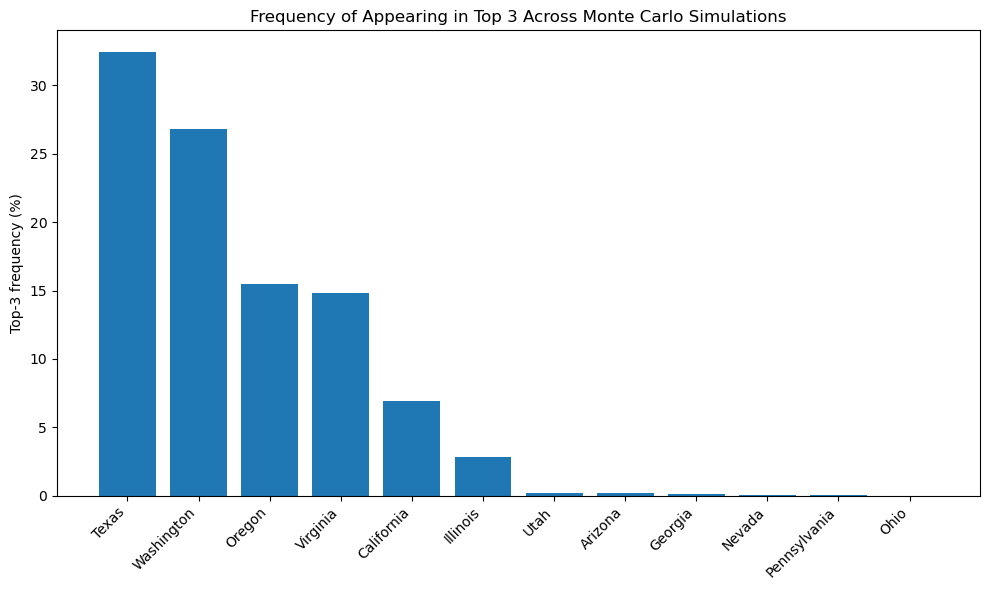

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    top3_frequency["State"],
    top3_frequency["Top_3_Frequency_Percent"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Top-3 frequency (%)")
plt.title("Frequency of Appearing in Top 3 Across Monte Carlo Simulations")
plt.tight_layout()

plt.show()